# **Preparing Dependancies**

In [ ]:
!pip install -q diffusers transformers

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter
from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionInpaintPipeline,
    StableDiffusionImg2ImgPipeline,
    EulerAncestralDiscreteScheduler,
    DPMSolverMultistepScheduler,
    DDIMScheduler
)
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [2]:
model_id = "runwayml/stable-diffusion-v1-5"

# Load Text-to-Image pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

# Move pipeline to GPU
pipe = pipe.to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

## **Generate Image**

  0%|          | 0/50 [00:00<?, ?it/s]

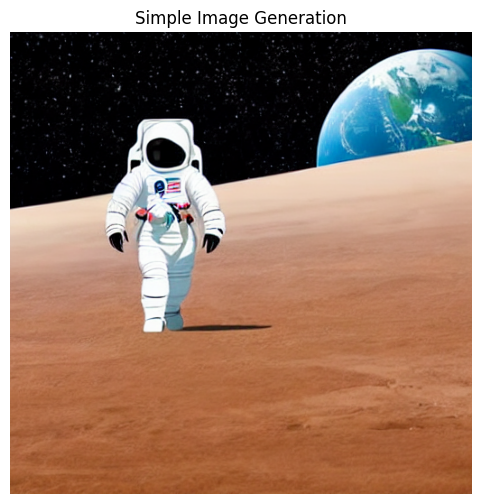

In [3]:
def generate_simple_image(prompt, negative_prompt, seed):
    generator = torch.Generator("cuda").manual_seed(seed)
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator
    ).images[0]
    return image

# Prompt setup & test parameters
prompt = "an astronaut with full white spacesuit, standing on a flat moon plain, with earth in the background, minimal detail, 2D digital illustration"
negative_prompt = "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"
seed = 222

# Execute function
simple_image = generate_simple_image(prompt, negative_prompt, seed)

# Display result
plt.figure(figsize=(6, 6))
plt.imshow(simple_image)
plt.axis("off")
plt.title("Simple Image Generation")
plt.show()

## **Generate Image with Hyperparameter Configuration**

  0%|          | 0/120 [00:00<?, ?it/s]

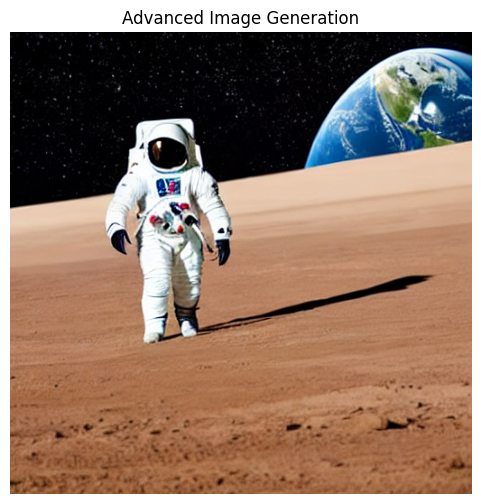

In [4]:
def generate_advanced_image(prompt, negative_prompt, seed, guidance_scale=10, num_inference_steps=120):
    generator = torch.Generator("cuda").manual_seed(seed)
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        generator=generator
    ).images[0]
    return image

# Execute function with identical parameters
advanced_image = generate_advanced_image(
    prompt=prompt,
    negative_prompt=negative_prompt,
    seed=seed,
    guidance_scale=10,
    num_inference_steps=120
)

# Display result
plt.figure(figsize=(6, 6))
plt.imshow(advanced_image)
plt.axis("off")
plt.title("Advanced Image Generation")
plt.show()

## **Guidance Scale Comparison**

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

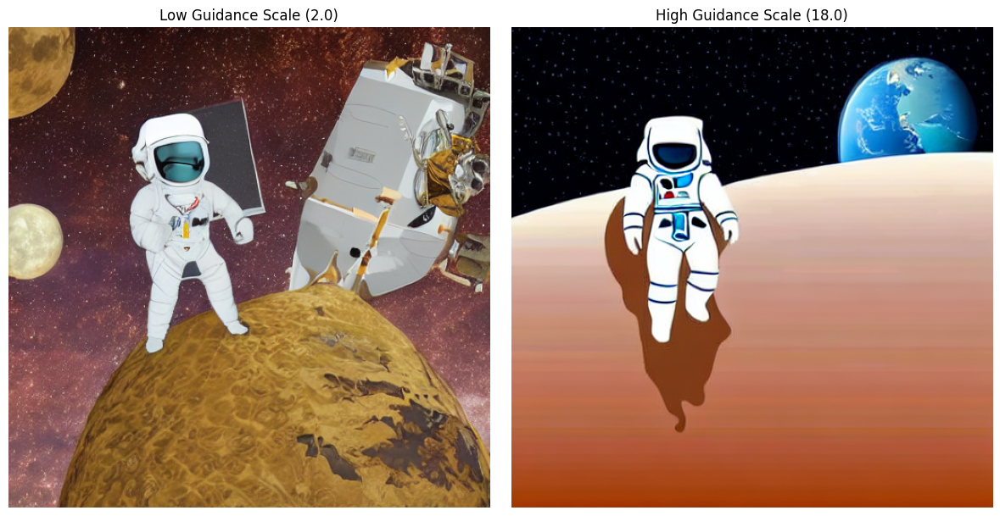

In [5]:
# Generate images with low and high guidance scale
img_low_cfg = generate_advanced_image(prompt, negative_prompt, seed, guidance_scale=2.0, num_inference_steps=30)
img_high_cfg = generate_advanced_image(prompt, negative_prompt, seed, guidance_scale=18.0, num_inference_steps=30)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_low_cfg)
axes[0].set_title("Low Guidance Scale (2.0)")
axes[0].axis("off")

axes[1].imshow(img_high_cfg)
axes[1].set_title("High Guidance Scale (18.0)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah:**   
*"Pada nilai guidance scale yang rendah (2.0), model diberikan kebebasan artistik yang terlalu tinggi sehingga kontrol dari teks prompt menjadi sangat lemah. Gambar yang dihasilkan memiliki kesesuaian prompt yang rendah dan memunculkan banyak elemen acak atau halusinasi visual yang tidak diminta dalam prompt, seperti potongan instrumen satelit di sebelah kanan, permukaan daratan bertekstur kasar, beberapa objek bulan tambahan, serta latar belakang nebula kemerahan. Elemen kunci seperti planet Bumi di latar belakang juga terabaikan."*

*   **Gambar dengan "Scale" Tinggi:**   
*"Pada nilai guidance scale yang tinggi (18.0), model dipaksa secara ketat untuk mematuhi seluruh instruksi kata kunci pada prompt. Dibandingkan dengan scale rendah, gambar ini menunjukkan tingkat kedekatan prompt yang sangat tinggi karena seluruh objek acak berhasil tereliminasi. Permukaan daratan menjadi datar, planet Bumi tercetak jelas di sudut kanan atas dengan latar belakang ruang angkasa hitam berbintang, serta gaya visualnya sangat konsisten dengan 2D digital illustration. Detail garis dan kontras warna juga tampak jauh lebih tegas dan terstruktur."*

## **Inference Steps Comparison**

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

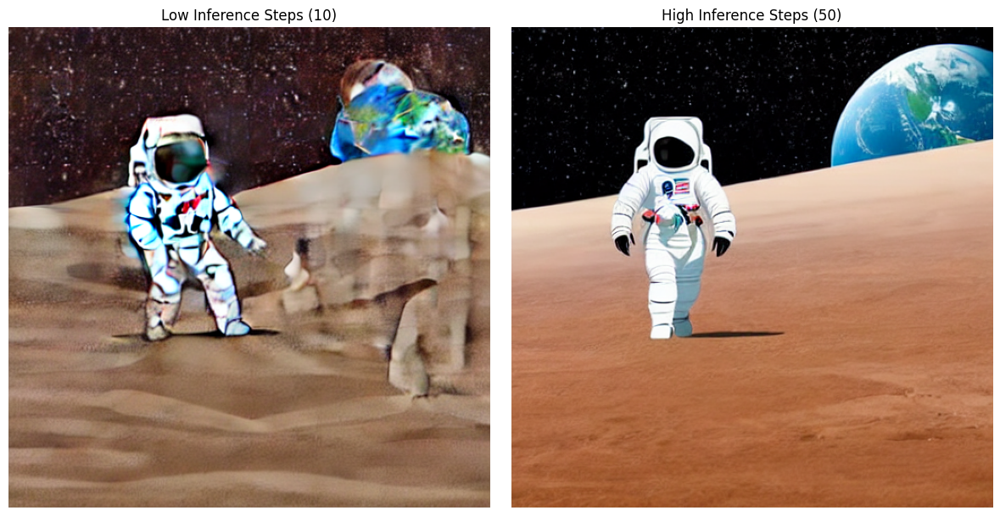

In [6]:
# Generate images with low and high inference steps
img_low_steps = generate_advanced_image(prompt, negative_prompt, seed, guidance_scale=7.5, num_inference_steps=10)
img_high_steps = generate_advanced_image(prompt, negative_prompt, seed, guidance_scale=7.5, num_inference_steps=50)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_low_steps)
axes[0].set_title("Low Inference Steps (10)")
axes[0].axis("off")

axes[1].imshow(img_high_steps)
axes[1].set_title("High Inference Steps (50)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah:**  
*"Pada jumlah inference steps yang rendah (10), proses denoising dari model difusi belum selesai secara sempurna sehingga gambar terlihat sangat buram dan belum matang. Detail objek astronot tampak terdistorsi dengan batas garis yang kabur, planet Bumi di latar belakang masih berbentuk gumpalan warna yang tidak terdefinisi, serta muncul banyak noise dan artefak visual berupa guratan tekstur yang tidak merata pada permukaan tanah."*
*   **Gambar dengan "Step" Tinggi:**  
*"Pada jumlah inference steps yang tinggi (50), proses denoising berjalan secara lengkap dan bertahap hingga mencapai konvergensi visual. Dibandingkan dengan step rendah, gambar ini menunjukkan tingkat kehalusan, ketajaman, dan stabilitas visual yang sangat baik. Proporsi dan detail baju astronot terdefinisi secara utuh, bayangan objek terbentuk dengan konsisten, serta planet Bumi dan hamparan bintang di ruang angkasa dapat terelaborasi secara bersih tanpa noise."*

## **Batch Inference from One Prompt**

  0%|          | 0/30 [00:00<?, ?it/s]

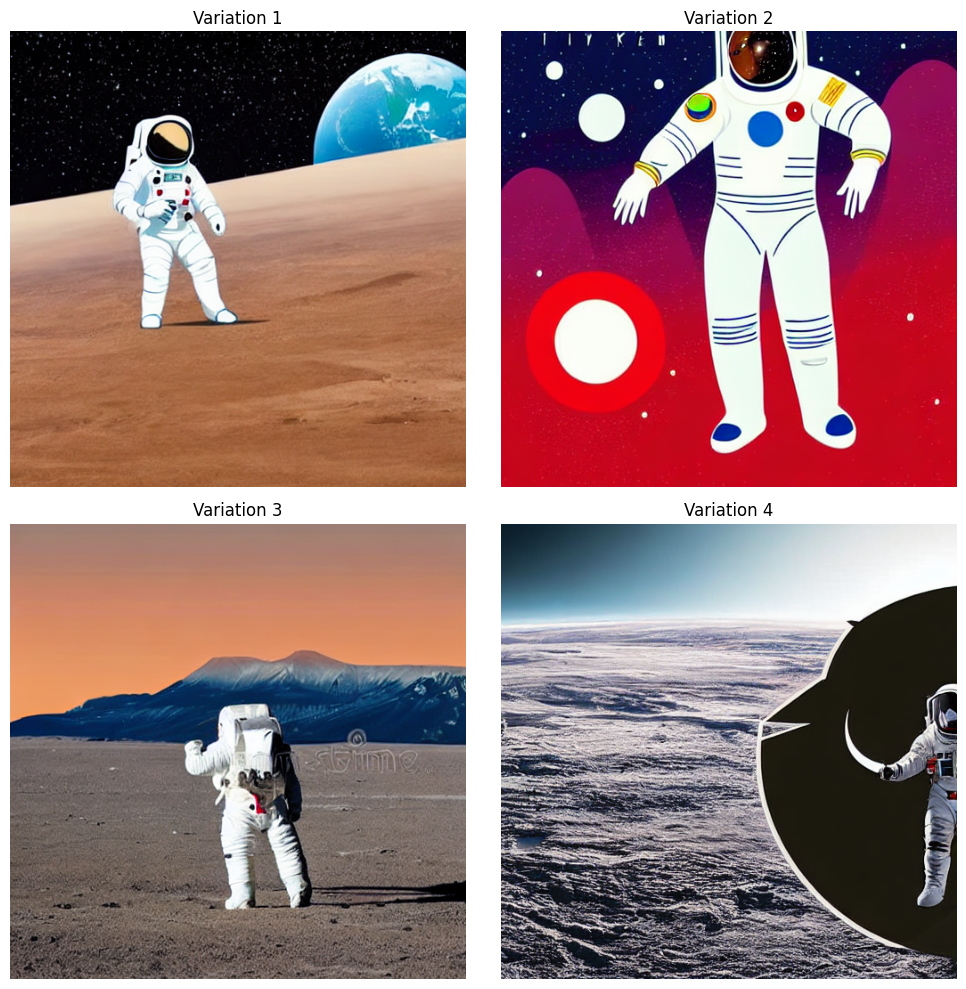

In [7]:
def generate_batch_images(prompt, negative_prompt, seed, num_images=4):
    generator = torch.Generator("cuda").manual_seed(seed)
    images = pipe(
        prompt=[prompt] * num_images,
        negative_prompt=[negative_prompt] * num_images,
        guidance_scale=7.5,
        num_inference_steps=30,
        generator=generator
    ).images
    return images

# Generate 4 images
batch_images = generate_batch_images(prompt, negative_prompt, seed, num_images=4)

# Plot 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for idx, img in enumerate(batch_images):
    ax = axes[idx // 2, idx % 2]
    ax.imshow(img)
    ax.set_title(f"Variation {idx+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## **Load Scheduler**

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

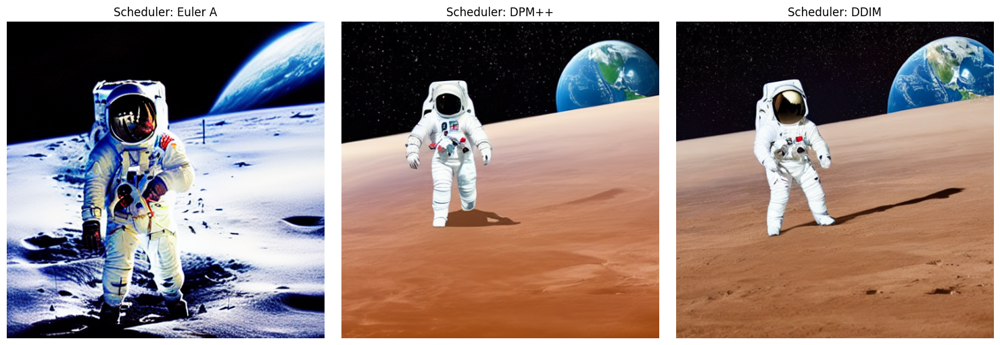

In [8]:
def load_scheduler(pipe, scheduler_name):
    if scheduler_name == "Euler A":
        pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    elif scheduler_name == "DPM++":
        pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
    elif scheduler_name == "DDIM":
        pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
    else:
        raise ValueError(f"Scheduler '{scheduler_name}' is not supported.")
    return pipe

# Compare 3 different schedulers
scheduler_names = ["Euler A", "DPM++", "DDIM"]
scheduler_results = {}

for name in scheduler_names:
    pipe = load_scheduler(pipe, name)
    generator = torch.Generator("cuda").manual_seed(seed)
    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        guidance_scale=7.5,
        num_inference_steps=30,
        generator=generator
    ).images[0]
    scheduler_results[name] = img

# Plot results for all 3 Schedulers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, name in enumerate(scheduler_names):
    axes[idx].imshow(scheduler_results[name])
    axes[idx].set_title(f"Scheduler: {name}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
*"Karakteristik gambar yang dihasilkan memiliki pencahayaan sinematik dengan kontras yang tinggi dan dominasi nada warna biru dingin. Tekstur pakaian astronot serta kawah pada permukaan tanah tampak sangat detail dan realistis dengan bayangan gelap yang tegas. Sifat dasar Euler A yang stochastic menghasilkan variasi visual yang dramatis."*
*   **Gambar dengan "DPM++ Scheduler":**  
*"Karakteristik gambar yang dihasilkan sangat bersih, rapi, dan paling konsisten dengan instruksi 2D digital illustration pada prompt. Hamparan tanah berwarna oranye-cokelat tampak mulus dengan gradasi warna yang halus, bayangan astronot terdefinisi secara lembut, serta planet Bumi dan ruang angkasa di latar belakang tergambar secara simetris tanpa noise."*
*   **Gambar dengan "DDIM Scheduler":**  
*"Karakteristik gambar yang dihasilkan tampil sangat seimbang dengan ketajaman dan stabilitas visual yang tinggi. Bagian visor astronot menghasilkan pantulan berkilau berwarna emas yang jernih, bayangan astronot terproyeksi secara realistis di atas tanah bertekstur halus, serta garis bentuk objek tercetak sangat stabil dan presisi."*

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Inpainting**

### **Load Model Inpainting**

In [9]:
inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


### **Manual Masking**

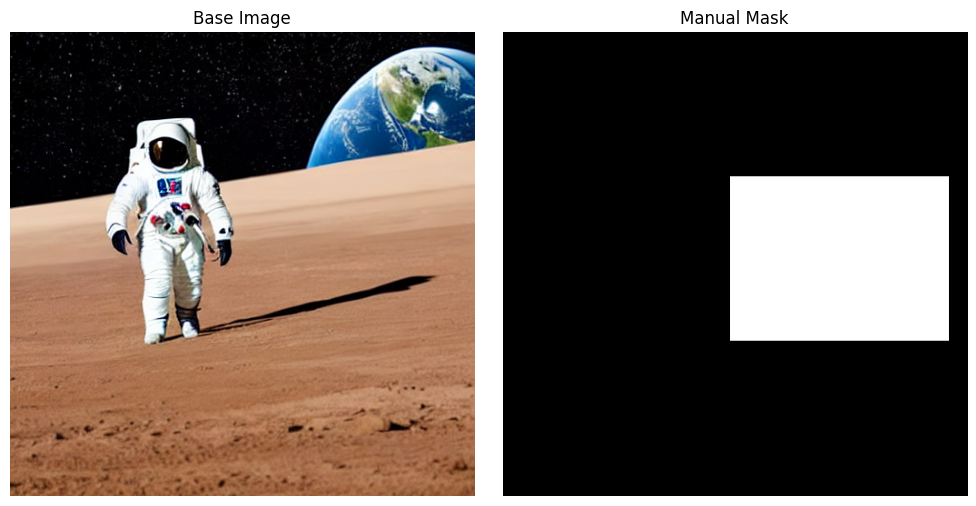

In [10]:
def inpaint_engine(image, mask, prompt, negative_prompt="", seed=9, guidance_scale=7.5, num_inference_steps=50):
    generator = torch.Generator("cuda").manual_seed(seed)
    result = inpaint_pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=image,
        mask_image=mask,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        generator=generator
    ).images[0]
    return result

# Prepare base image
base_img = advanced_image.resize((512, 512))

# Create manual mask for the satellite area
manual_mask = Image.new("L", base_img.size, 0)
draw = ImageDraw.Draw(manual_mask)

# Define rectangular target area for satellite
draw.rectangle([250, 160, 490, 340], fill=255)

# Plot base image and manual mask
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(base_img)
axes[0].set_title("Base Image")
axes[0].axis("off")

axes[1].imshow(manual_mask, cmap="gray")
axes[1].set_title("Manual Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

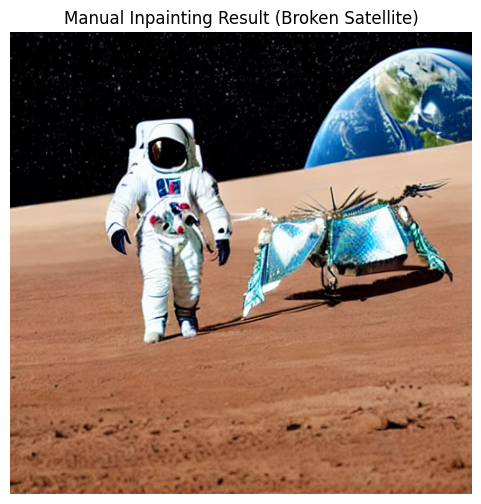

In [11]:
# Setup inpainting prompt & negative prompt
inpaint_prompt = "a broken angular space satellite with shiny silver and cyan metallic wings, golden foil insulation, antennas, crashed on moon surface, detailed sci-fi illustration"
inpaint_negative = "boxy satellite, cube, blurry, low quality, bad art, ugly, distorted, grainy"

# Execute inpainting
inpainted_image = inpaint_engine(
    image=base_img,
    mask=manual_mask,
    prompt=inpaint_prompt,
    negative_prompt=inpaint_negative,
    seed=9,
    guidance_scale=11.5,
    num_inference_steps=50
)

# Display result
plt.figure(figsize=(6, 6))
plt.imshow(inpainted_image)
plt.axis("off")
plt.title("Manual Inpainting Result (Broken Satellite)")
plt.show()

## **Inpainting Menggunakan Automasking**

### **load Model Segmentation Untuk Masking**

In [12]:
segment_processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
segment_model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.73k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  603MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

### **Masking with Segmentation Model**

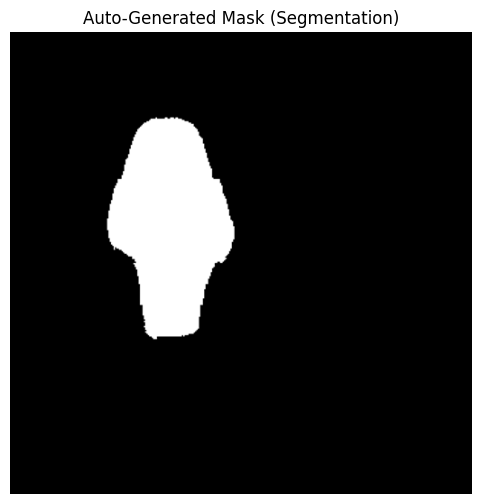

In [13]:
def create_auto_mask(image, text_prompt, threshold=0.4):
    inputs = segment_processor(text=[text_prompt], images=[image], return_tensors="pt")
    with torch.no_grad():
        outputs = segment_model(**inputs)

    # Process output logits with sigmoid and squeeze
    preds = torch.sigmoid(outputs.logits)
    mask_np = preds.squeeze().cpu().numpy()

    # Binarize mask based on threshold
    binary_mask = (mask_np > threshold).astype(np.uint8) * 255
    auto_mask = Image.fromarray(binary_mask).resize(image.size)
    return auto_mask

# Generate auto mask
auto_mask = create_auto_mask(inpainted_image, text_prompt="astronaut", threshold=0.3)

# Display auto-generated mask
plt.figure(figsize=(6, 6))
plt.imshow(auto_mask, cmap="gray")
plt.axis("off")
plt.title("Auto-Generated Mask (Segmentation)")
plt.show()

### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

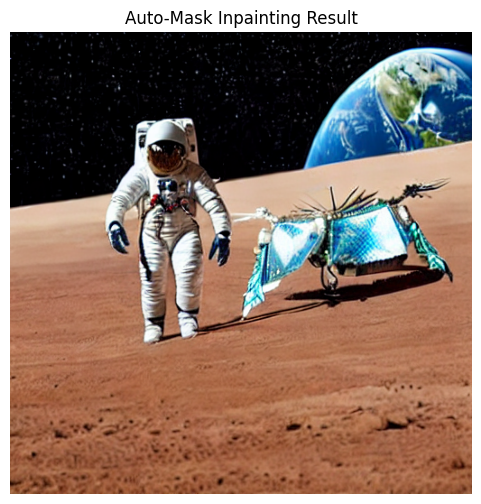

In [14]:
# Setup prompt for auto-mask inpainting
auto_inpaint_prompt = "an astronaut in glowing futuristic golden mechanical spacesuit, detailed sci-fi suit"

# Execute inpainting with auto mask
auto_inpainted_image = inpaint_engine(
    image=inpainted_image,
    mask=auto_mask,
    prompt=auto_inpaint_prompt,
    negative_prompt=inpaint_negative,
    seed=9
)

# Display result
plt.figure(figsize=(6, 6))
plt.imshow(auto_inpainted_image)
plt.axis("off")
plt.title("Auto-Mask Inpainting Result")
plt.show()

## **Outpainting**

### **Prepare the Canvas**

In [15]:
def prepare_outpainting(image, direction="right", padding=128, overlap=24):
    width, height = image.size

    if direction == "right":
        new_width, new_height = width + padding, height
        new_image = Image.new("RGB", (new_width, new_height), (0, 0, 0))
        new_image.paste(image, (0, 0))

        mask = Image.new("L", (new_width, new_height), 255)
        mask.paste(Image.new("L", (width - overlap, height), 0), (0, 0))

    elif direction == "left":
        new_width, new_height = width + padding, height
        new_image = Image.new("RGB", (new_width, new_height), (0, 0, 0))
        new_image.paste(image, (padding, 0))

        mask = Image.new("L", (new_width, new_height), 255)
        mask.paste(Image.new("L", (width - overlap, height), 0), (padding + overlap, 0))

    elif direction == "top":
        new_width, new_height = width, height + padding
        new_image = Image.new("RGB", (new_width, new_height), (0, 0, 0))
        new_image.paste(image, (0, padding))

        mask = Image.new("L", (new_width, new_height), 255)
        mask.paste(Image.new("L", (width, height - overlap), 0), (0, padding + overlap))

    elif direction == "bottom":
        new_width, new_height = width, height + padding
        new_image = Image.new("RGB", (new_width, new_height), (0, 0, 0))
        new_image.paste(image, (0, 0))

        mask = Image.new("L", (new_width, new_height), 255)
        mask.paste(Image.new("L", (width, height - overlap), 0), (0, 0))

    return new_image, mask

# Prepare expanded canvas
expanded_canvas, outpaint_mask = prepare_outpainting(inpainted_image, direction="right", padding=128, overlap=24)

### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

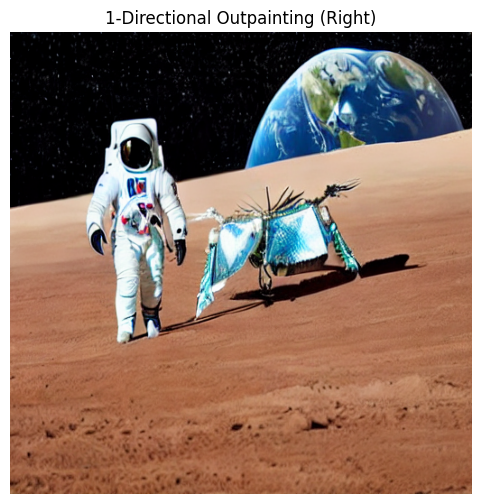

In [16]:
# Setup outpainting prompt
outpaint_prompt = "flat moon plain, endless rocky landscape, starry space background, high detail, seamless transition"
outpaint_negative = "photorealistic, 3d render, blurry, low quality, distorted, lines, vertical seam"

# Execute outpainting
outpainted_image = inpaint_engine(
    image=expanded_canvas,
    mask=outpaint_mask,
    prompt=outpaint_prompt,
    negative_prompt=outpaint_negative,
    seed=9,
    guidance_scale=8.0,
    num_inference_steps=50
)

# Display result
plt.figure(figsize=(8, 6))
plt.imshow(outpainted_image)
plt.axis("off")
plt.title("1-Directional Outpainting (Right)")
plt.show()

## **Outpainting Zoom Out**

### **Prepare Canvas for Zoom Out**

In [17]:
def prepare_zoom_out_canvas(image, zoom_factor=0.65, canvas_size=(512, 512), overlap=16):
    orig_w, orig_h = image.size
    new_w = int(orig_w * zoom_factor)
    new_h = int(orig_h * zoom_factor)
    resized_image = image.resize((new_w, new_h), Image.Resampling.LANCZOS)

    # Create black canvas
    canvas_w, canvas_h = canvas_size
    new_canvas = Image.new("RGB", (canvas_w, canvas_h), (0, 0, 0))

    # Paste scaled image directly in center
    paste_x = (canvas_w - new_w) // 2
    paste_y = (canvas_h - new_h) // 2
    new_canvas.paste(resized_image, (paste_x, paste_y))

    # Create mask
    mask = Image.new("L", (canvas_w, canvas_h), 255)

    # Keep center preserved
    inner_w = new_w - (2 * overlap)
    inner_h = new_h - (2 * overlap)
    inner_x = paste_x + overlap
    inner_y = paste_y + overlap
    mask.paste(Image.new("L", (inner_w, inner_h), 0), (inner_x, inner_y))

    # Light blur to smooth transition
    mask = mask.filter(ImageFilter.GaussianBlur(radius=3))

    return new_canvas, mask

# Prepare canvas for zoom out
zoom_canvas, zoom_mask = prepare_zoom_out_canvas(inpainted_image, zoom_factor=0.65, canvas_size=(512, 512), overlap=16)

### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

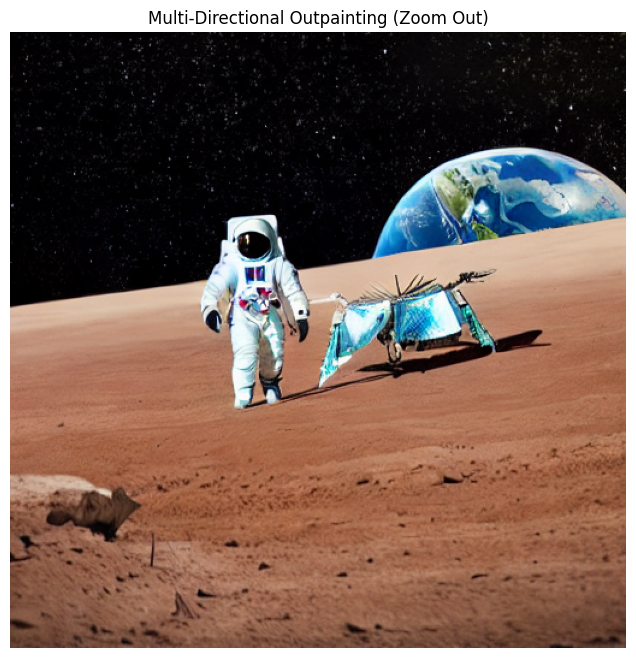

In [18]:
# Setup zoom out prompt & negative prompt
zoom_prompt = "wide shot of astronaut on moon plain surface, starry dark space background, earth in upper right sky, 2D digital illustration"
zoom_negative = "satellite, extra satellite, duplicate objects, vignette, circular frame, telescope view, border, black ring, lens effect, duplicate earth, second moon, extra planets, blurry"

# Execute zoom out outpainting
zoom_out_result = inpaint_engine(
    image=zoom_canvas,
    mask=zoom_mask,
    prompt=zoom_prompt,
    negative_prompt=zoom_negative,
    seed=9,
    guidance_scale=7.5,
    num_inference_steps=50
)

# Display result
plt.figure(figsize=(8, 8))
plt.imshow(zoom_out_result)
plt.axis("off")
plt.title("Multi-Directional Outpainting (Zoom Out)")
plt.show()

## **Base + Refiner Image Generation**

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

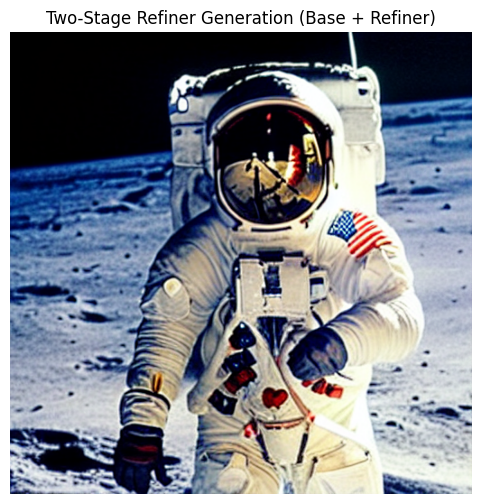

In [19]:
# Load Img2Img pipeline using existing weights
pipe_img2img = StableDiffusionImg2ImgPipeline.from_pipe(pipe).to("cuda")

# Setup prompt & seed
refiner_prompt = "an astronaut with full white spacesuit, standing on a flat moon plain, with earth in the background, highly detailed, sharp focus"
seed = 222

# Stage 1: Base Model
generator = torch.Generator("cuda").manual_seed(seed)
stage1_latents = pipe(
    prompt=refiner_prompt,
    negative_prompt=negative_prompt,
    guidance_scale=7.5,
    num_inference_steps=40,
    denoising_end=0.8,
    output_type="latent",
    generator=generator
).images

# Decode Stage 1 latents to PIL Image to prevent double VAE encoding
with torch.no_grad():
    decoded_latents = pipe.vae.decode(stage1_latents / pipe.vae.config.scaling_factor, return_dict=False)[0]
    stage1_image = pipe.image_processor.postprocess(decoded_latents, output_type="pil")[0]

# Stage 2: Refiner Model
generator = torch.Generator("cuda").manual_seed(seed)
refiner_result = pipe_img2img(
    prompt=refiner_prompt,
    negative_prompt=negative_prompt,
    image=stage1_image,
    guidance_scale=7.5,
    num_inference_steps=40,
    denoising_start=0.8,
    generator=generator
).images[0]

# Display result
plt.figure(figsize=(6, 6))
plt.imshow(refiner_result)
plt.axis("off")
plt.title("Two-Stage Refiner Generation (Base + Refiner)")
plt.show()